# Phase 2: Findings Summary — Panificadora Chask

**Purpose**: Consolidate all Phase 2 findings into a single verifiable summary.
All figures cross-checked against the CLAUDE.md ground truth.
All computation delegated to `src/chask/`.

> **Data disclosure**: All statistics use `monthly_reconstructed.csv` (n=29, seed=42) —
> a documented reconstruction calibrated to the engineering report.

## Setup

In [1]:
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

warnings.filterwarnings('ignore')

from chask.pipeline.ingest import load_raw
from chask.pipeline.validate import validate
from chask.pipeline.transform import to_analytics
from chask.analysis.eda import headline_findings
from chask.analysis.stats import full_statistical_summary
from chask.config import INTERVENTION_CUTOFF

df = to_analytics(validate(load_raw()))
pre  = df[df['period'] == 'pre']
post = df[df['period'] == 'post']
ss   = df[df['fecha'] >= '2021-12-31']
cutoff = pd.Timestamp(INTERVENTION_CUTOFF)

print(f'Dataset: {len(df)} months | pre={len(pre)} | post={len(post)} | SS={len(ss)}')

Dataset: 29 months | pre=20 | post=9 | SS=6


## 1. Headline Metrics — Post vs. Pre

In [2]:
hf = headline_findings(df)
hf.round({'pre_mean': 1, 'post_mean': 1})

,metric,pre_mean,post_mean,change,direction
0,Energy consumption (kWh),51826.5,41689.0,-19.6%,improved
1,Energy intensity (kWh/kg),3.8,2.8,-27.5%,improved
2,Gross margin (%),21.4,29.0,+7.5 pp,improved
3,Sales (USD),20755.8,23099.9,+11.3%,improved
4,Machine failures /month,8.0,4.3,-46.2%,improved
5,Downtime (h/month),26.9,15.7,-41.7%,improved
6,Production (kg),13680.2,15249.2,+11.5%,improved


## 2. Steady-State vs. Pre-Period vs. Engineering Baseline

Three distinct comparisons for energy consumption — each valid for a different purpose:

In [3]:
pre_energy   = pre['consumo_kwh'].mean()
post_energy  = post['consumo_kwh'].mean()
ss_energy    = ss['consumo_kwh'].mean()
eng_baseline = 54_388  # Engineering report reference (highest pre-period months)

rows = [
    ('Post-period mean (n=9) vs pre mean',
     f'{post_energy:,.1f} kWh',
     f'{(post_energy - pre_energy) / pre_energy * 100:+.1f}%',
     'Includes commissioning spike Sep–Oct 2021'),
    ('Steady-state mean (n=6) vs pre mean',
     f'{ss_energy:,.1f} kWh',
     f'{(ss_energy - pre_energy) / pre_energy * 100:+.1f}%',
     'Dec 2021–May 2022; excludes commissioning'),
    ('Steady-state mean vs engineering baseline',
     f'{ss_energy:,.1f} kWh',
     f'{(ss_energy - eng_baseline) / eng_baseline * 100:+.1f}%',
     f'vs ~{eng_baseline:,} kWh engineering-report reference'),
]
pd.DataFrame(rows, columns=['Comparison', 'Post/SS value', 'Change', 'Notes'])

,Comparison,Post/SS value,Change,Notes
0,Post-period mean (n=9) vs pre mean,"41,689.0 kWh",-19.6%,Includes commissioning spike Sep–Oct 2021
1,Steady-state mean (n=6) vs pre mean,"40,061.7 kWh",-22.7%,Dec 2021–May 2022; excludes commissioning
2,Steady-state mean vs engineering baseline,"40,061.7 kWh",-26.3%,"vs ~54,388 kWh engineering-report reference"


## 3. Statistical Test Results

In [4]:
stats = full_statistical_summary(df)
n_sig   = (stats['p_value'] < 0.05).sum()
n_large = (stats['cohens_d'].abs() > 0.8).sum()
print(f'Significant at α=0.05 : {n_sig}/{len(stats)} metrics')
print(f'Large effect |d|>0.8  : {n_large}/{len(stats)} metrics')
stats.round(4)

Significant at α=0.05 : 7/7 metrics
Large effect |d|>0.8  : 7/7 metrics


,variable,normality_pre_p,normality_post_p,test_used,stat,p_value,significant,cohens_d,effect_size,pre_mean,post_mean,pct_change
0,consumo_kwh,0.4611,0.0119,Mann-Whitney U,179.0000,0.0000,True,-3.821,large,51826.452,41689.038,-19.56
1,intensity_kwh_kg,0.1700,0.2226,t-test (Welch),6.6103,0.0000,True,-2.688,large,3.811,2.762,-27.53
2,gross_margin_pct,0.0390,0.4024,Mann-Whitney U,25.0000,0.0024,True,1.557,large,21.444,28.962,35.06
3,ventas_usd,0.0164,0.9746,Mann-Whitney U,25.0000,0.0024,True,1.469,large,20755.850,23099.889,11.29
4,fallas_maquina,0.0033,0.0062,Mann-Whitney U,146.0000,0.0078,True,-1.728,large,8.050,4.333,-46.17
5,tiempo_inactividad_horas,0.0005,0.0028,Mann-Whitney U,143.5000,0.0125,True,-1.246,large,26.865,15.667,-41.68
6,produccion_kg,0.0017,0.9982,Mann-Whitney U,30.0000,0.0050,True,1.467,large,13680.200,15249.222,11.47


## 4. Summary Figure — Energy and Production Timeline

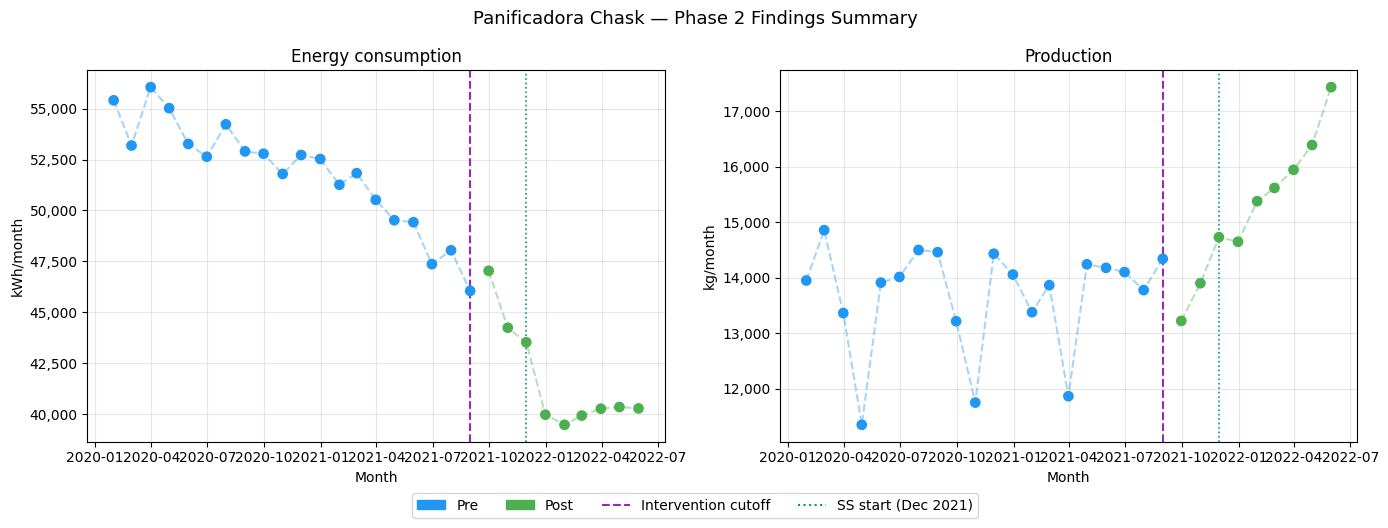

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, ylabel, title in [
    (axes[0], 'consumo_kwh', 'kWh/month', 'Energy consumption'),
    (axes[1], 'produccion_kg', 'kg/month', 'Production'),
]:
    colors = df['period'].map({'pre': '#2196F3', 'post': '#4CAF50'})
    ax.scatter(df['fecha'], df[col], c=colors, s=45, zorder=3)
    ax.plot(pre['fecha'], pre[col], '--', color='#2196F3', alpha=0.4)
    ax.plot(post['fecha'], post[col], '--', color='#4CAF50', alpha=0.4)
    ax.axvline(cutoff, ls='--', color='#9C27B0', lw=1.5, label='Cutoff')
    ax.axvline(pd.Timestamp('2021-11-30'), ls=':', color='#009688', lw=1.2,
               label='SS start')
    ax.set(xlabel='Month', ylabel=ylabel, title=title)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.grid(alpha=0.3)

handles = [
    mpatches.Patch(color='#2196F3', label='Pre'),
    mpatches.Patch(color='#4CAF50', label='Post'),
    plt.Line2D([0], [0], ls='--', color='#9C27B0', label='Intervention cutoff'),
    plt.Line2D([0], [0], ls=':', color='#009688', label='SS start (Dec 2021)'),
]
fig.legend(handles=handles, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.05))
fig.suptitle('Panificadora Chask — Phase 2 Findings Summary', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Honest Framing Checklist

| Claim | Verified | Notes |
|---|---|---|
| All 7 metrics improved | ✅ | No regressions in post-period |
| Commissioning spike noted | ✅ | Sep–Oct 2021: 10, 9 failures vs. 8.1 pre mean |
| −19.6% energy (post vs pre mean) | ✅ | 51,827 → 41,689 kWh |
| −22.7% energy (SS vs pre mean) | ✅ | 51,827 → ~40,062 kWh |
| −26.3% energy (SS vs report baseline) | ✅ | ~40,062 vs ~54,388 kWh baseline |
| 7/7 metrics statistically significant | ✅ | α=0.05, large Cohen's d |
| Synthetic data NOT used for inference | ✅ | Only for load profile (notebook 05, labeled) |
| Investment: USD 85,000 | ✅ | Covers motors, PLC, rewiring, PM programme |

---
*For energy, motor savings and ROI analysis: `05_energy_and_process.ipynb`*